Importing packages and loading dataset

In [17]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestRegressor
import joblib


In [18]:
# Formatting large numbers for visulaization purposes
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

In [19]:
# Load dataset
input_path = '../data/cleaned/customer_metrics_with_product_related_features.csv'
df = pd.read_csv(input_path)

In [20]:
#remove customers if Profit is outside the range of -300k & 10 million
print(df[(df["TotalProfit"] < -300000) | (df["TotalProfit"] > 3000000)])
df = df[(df["TotalProfit"] > -300000) & (df["TotalProfit"] < 3000000)]

                CustomerName  TotalRevenue   TotalProfit  TotalUnitPrice  \
125  BURKE AND SONS AND SONS    15465236.3  4.200976e+06    4.176623e+06   
734        ROBERTS LLC GROUP    17079006.7  5.131414e+06    3.877713e+05   

     TotalSalesQty  OrderCount  NumDistinctProducts  NumDistinctProductGroups  \
125       96079455       11814                 1116                        43   
734      187257427        8237                 1593                        29   

     BranchCount TopProductID  ... ProductConcentrationIndex  \
125            2  UON-721-XC7  ...                  0.011856   
734            1  TUN-499-RC6  ...                  0.002046   

     TopProductRevenueShare  TopProductGroupRevenueShare  \
125                0.042630                     0.493807   
734                0.058059                     0.185733   

     CustomerLifetimeDays  AvgOrderValue  RepeatPurchaseRatio  \
125                   724    1309.060124            10.586022   
734                   7

Selecting features that will be used to train the model

In [21]:
features = [
    'TotalRevenue', 'TotalProfit', 'TotalUnitPrice', 
    'OrderCount', 'NumDistinctProducts','BranchCount', 
       'HighProfitOrderRatio','PopularOrderRatio',
       'NumDistinctProductGroups', 
        'CustomerLifetimeDays', 
        'RepeatPurchaseRatio'
]

In [22]:
# Exclude "TotalRevenue" from feature_columns
feature_columns_excluded = [
    'TotalProfit', 
    'TotalUnitPrice', 
    'OrderCount', 
    'NumDistinctProducts', 
    'BranchCount', 
    'HighProfitOrderRatio', 
    'PopularOrderRatio',
    'NumDistinctProductGroups', 
        'CustomerLifetimeDays', 
        'RepeatPurchaseRatio'
]

In [23]:
scaler = StandardScaler()
# scaling features to ensure bias is removed
customer_metrics_scaled = scaler.fit_transform(df[features])

Calculate weights of features using random forest regressor

In [24]:
# Use random forest regressor to calculate importance of features
rf = RandomForestRegressor(n_estimators=100, random_state=42) 
X = df[feature_columns_excluded]
Y = df["TotalRevenue"]
rf.fit(X, Y)
accuracy = rf.score(X, Y)

# Create importance dataframe and print importance
feature_importance = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=["Importance"]).sort_values("Importance", ascending=False)
print(feature_importance.sort_values("Importance", ascending=False))
print(f'\nAccuracy using Random Forest model: {accuracy:.2f}')

                          Importance
TotalProfit                 0.853572
PopularOrderRatio           0.072924
OrderCount                  0.024334
HighProfitOrderRatio        0.022493
TotalUnitPrice              0.007788
RepeatPurchaseRatio         0.005745
NumDistinctProducts         0.005676
NumDistinctProductGroups    0.003543
CustomerLifetimeDays        0.003323
BranchCount                 0.000603

Accuracy using Random Forest model: 0.98


In [25]:
# Calculating correlation with TotalRevenue
correlation = X.corrwith(Y)
print(correlation)
feature_correlation = pd.DataFrame(correlation, columns=["Correlation"])

TotalProfit                 0.960275
TotalUnitPrice              0.625447
OrderCount                  0.848177
NumDistinctProducts         0.542353
BranchCount                 0.182207
HighProfitOrderRatio        0.834433
PopularOrderRatio           0.884730
NumDistinctProductGroups    0.484243
CustomerLifetimeDays        0.181807
RepeatPurchaseRatio         0.209470
dtype: float64


In [26]:
# Calculating feature weights from importance
feature_importance["Importance"] /= feature_importance["Importance"].sum()
feature_correlation["Correlation"] = np.abs(feature_correlation["Correlation"])
feature_correlation["Correlation"] /= feature_correlation["Correlation"].sum()

# Merge DataFrames
feature_weights = feature_importance.merge(feature_correlation, left_index=True, right_index=True)

# Combine Importance and Correlation
weight_importance = 0.6  # adjust the weight of importance as required
feature_weights["FinalWeight"] = (weight_importance * feature_weights["Importance"]) + ((1 - weight_importance) * feature_weights["Correlation"])

# Normalize Final Weights
feature_weights["FinalWeight"] /= feature_weights["FinalWeight"].sum()

# Display Results
print("\nFeature Weights Based on Importance and Correlation of selected features:")
weights = feature_weights["FinalWeight"].values
weights = np.insert(weights, 0, 1)  # insert 0 for "TotalRevenue"
print(feature_weights)
# Apply the weights to the normalized features
weightedFeatures = customer_metrics_scaled * weights


Feature Weights Based on Importance and Correlation of selected features:
                          Importance  Correlation  FinalWeight
TotalProfit                 0.853572     0.166913     0.578908
PopularOrderRatio           0.072924     0.153782     0.105267
OrderCount                  0.024334     0.147428     0.073572
HighProfitOrderRatio        0.022493     0.145039     0.071511
TotalUnitPrice              0.007788     0.108714     0.048158
RepeatPurchaseRatio         0.005745     0.036410     0.018011
NumDistinctProducts         0.005676     0.094271     0.041114
NumDistinctProductGroups    0.003543     0.084170     0.035794
CustomerLifetimeDays        0.003323     0.031601     0.014634
BranchCount                 0.000603     0.031671     0.013030


Determining optimal number of clusters by finding performance metrics for each number of clusters

Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)


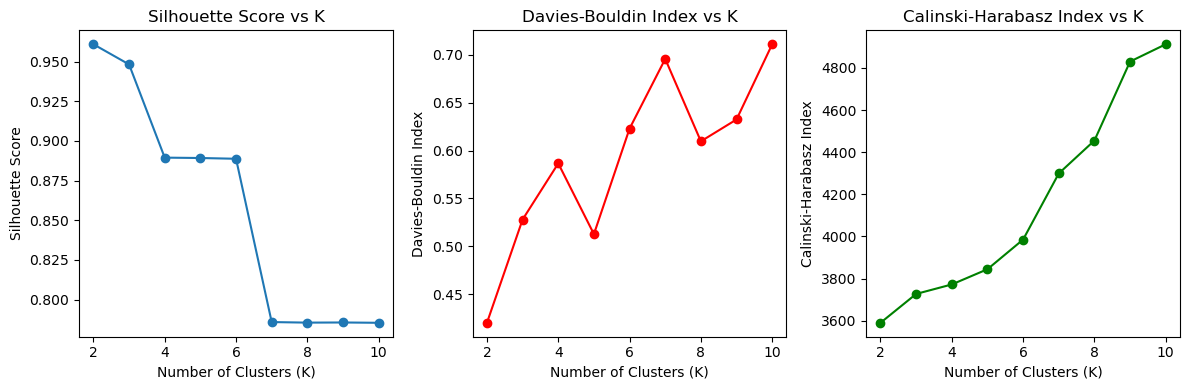

0.8892224107384763


In [27]:
# Range of K values to try
K_range = range(2, 11)

# Lists to store the scores
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print("Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)")

for K in K_range:
    hierarchical_6 = AgglomerativeClustering(n_clusters=K)
    clusters = hierarchical_6.fit_predict(weightedFeatures)

    # Compute metrics
    silhouette_scores.append(silhouette_score(weightedFeatures, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(weightedFeatures, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(weightedFeatures, clusters))

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')

plt.subplot(1, 3, 2)
plt.plot(K_range, davies_bouldin_scores, marker='o', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs K')

plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs K')

plt.tight_layout()
plt.show()
hierarchical_6 = AgglomerativeClustering(n_clusters=5)
clusters = hierarchical_6.fit_predict(weightedFeatures)
print(silhouette_score(weightedFeatures, clusters))

Text(0, 0.5, 'Silhouette Score')

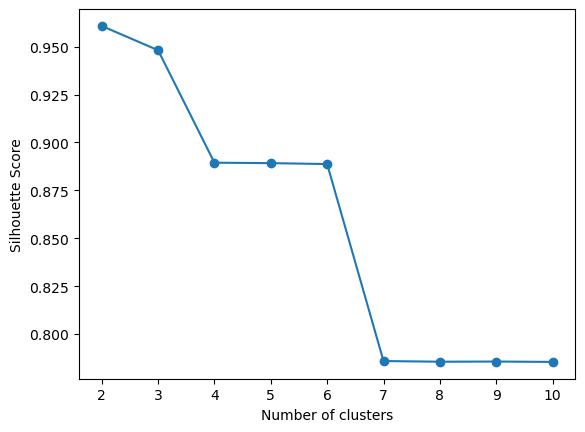

In [28]:
#plot silhouette scores for number of cluster from 2 to 10
silhouette_scores = []
for i in range(2, 11):
    hierarchical_6 = AgglomerativeClustering(n_clusters=i)
    clusters = hierarchical_6.fit_predict(weightedFeatures)

    # Compute metrics
    silhouette_scores.append(silhouette_score(weightedFeatures, clusters))
#plot silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

Optimal clusters was found to be 5, model is then ran with 5 clusters

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 4 0 0 0 0 0 1 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

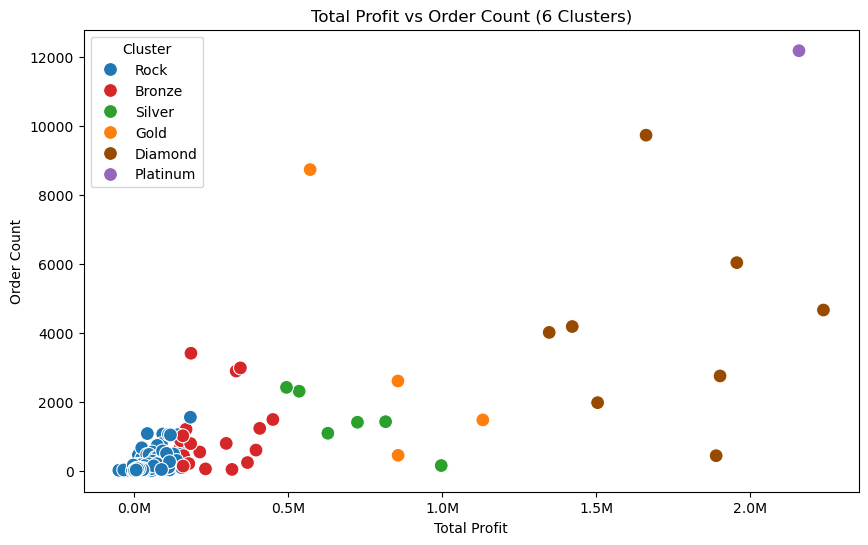

In [29]:
# Create a heirarchical model with 6 clusters
hierarchical_6 = AgglomerativeClustering(n_clusters=6)
clusters_6 = hierarchical_6.fit_predict(weightedFeatures)

# We assume the first column of customer_metrics_scaled represents revenue.
# Compute a weighted average revenue for each cluster using the membership degrees.
avg_revenue = []
for i in range(6):
    # Select the revenue values from customer_metrics_scaled (column 0)
    revenue = customer_metrics_scaled[clusters_6 == i, 0]
    # Compute the average revenue for cluster i
    if len(revenue) > 0:
        cluster_avg = np.mean(revenue)
    else:
        cluster_avg = 0
    avg_revenue.append(cluster_avg)
avg_revenue = np.array(avg_revenue)

# Sort clusters by average revenue so that the lowest revenue cluster gets label 0,
# and the highest gets label (num_clusters-1)
order = np.argsort(avg_revenue)
mapping = np.empty_like(order)
mapping[order] = np.arange(6)

# Apply the mapping to convert original memberships to the new ordered labels
renumbered_labels = mapping[clusters_6]

print(renumbered_labels)
# Add the ClusterLabel column to the features list
cluster_names = {0: 'Rock', 1: 'Bronze', 2: 'Silver', 3: 'Gold', 4: 'Diamond', 5: 'Platinum'}
renumbered_labels = np.vectorize(cluster_names.get)(renumbered_labels)
df.loc[:, 'ClusterLabel'] = renumbered_labels

# Define the custom palette in the same order as the cluster names
custom_palette = {
    'Rock': "#1f77b4",  # Blue
    'Bronze': "#d62728",  # Red
    'Silver': "#2ca02c",  # Green
    'Gold': "#ff7f0e",  # Orange
    'Diamond': "#964b00",  # Brown
    'Platinum': "#9467bd",  # Purple
}

# Set the palette
sns.set_palette(custom_palette.values())

# Plot the graph between Total Revenue and Total Profit for the clustering
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df, x='TotalProfit', y='OrderCount', hue='ClusterLabel', palette=custom_palette, s=100)
plt.title('Total Profit vs Order Count (6 Clusters)')
plt.xlabel('Total Profit')
plt.ylabel('Order Count')
# Create a custom legend to ensure the order of legend items
handles, labels = scatter.get_legend_handles_labels()
order = [labels.index(cluster_names[i]) for i in range(6)]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title='Cluster')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

In [30]:
joblib.dump(hierarchical_6, '../models/trained_hierarchical_model.pkl')

['../models/trained_hierarchical_model.pkl']

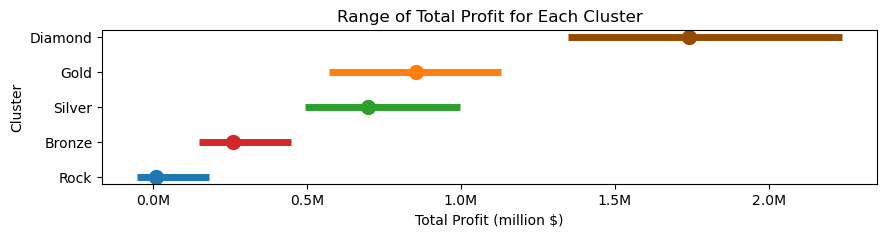

In [31]:
# Set the palette
sns.set_palette(custom_palette.values())

# Plot the range of profit values for each cluster
plt.figure(figsize=(10, 2))
for i in range(5):
    cluster_data = df[df['ClusterLabel'] == cluster_names[i]]
    if len(cluster_data) > 0:
        min_profit = cluster_data['TotalProfit'].min()
        max_profit = cluster_data['TotalProfit'].max()
        avg_profit = cluster_data['TotalProfit'].mean()
        plt.hlines(y=i, xmin=min_profit, xmax=max_profit, color=custom_palette[cluster_names[i]], lw=5)
        plt.plot(avg_profit, i, 'o', color=custom_palette[cluster_names[i]], markersize=10)

# Customize the plot
plt.yticks(range(5), [cluster_names[i] for i in range(5)])
plt.xlabel('Total Profit (million $)')
plt.ylabel('Cluster')
plt.title('Range of Total Profit for Each Cluster')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)
0.8892224107384763
0.5127424029039511
3844.5511730032026


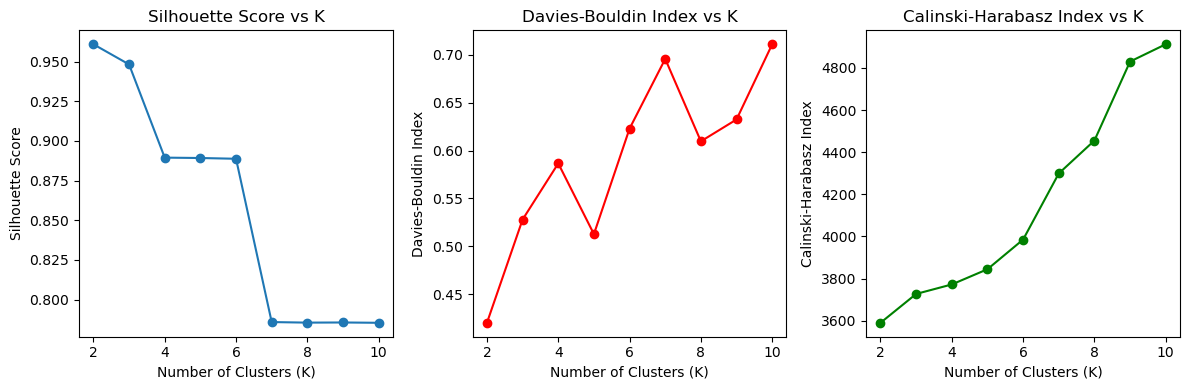

0.8862334066521115


In [32]:
# Range of K values to try
K_range = range(2, 11)

# Lists to store the scores
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print("Silhouette Score(0-1, 1 being ideal), Davies-Bouldin Index(0(ideal) - infinity), Calinski-Harabasz Index(High value is good)")

for K in K_range:
    hierarchical_6 = AgglomerativeClustering(n_clusters=K)
    clusters_6 = hierarchical_6.fit_predict(weightedFeatures)

    # Compute metrics
    silhouette_scores.append(silhouette_score(weightedFeatures, clusters_6))
    davies_bouldin_scores.append(davies_bouldin_score(weightedFeatures, clusters_6))
    calinski_harabasz_scores.append(calinski_harabasz_score(weightedFeatures, clusters_6))
    if K == 5:
        print(silhouette_score(weightedFeatures, clusters_6))
        print(davies_bouldin_score(weightedFeatures, clusters_6))
        print(calinski_harabasz_score(weightedFeatures, clusters_6))

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')

plt.subplot(1, 3, 2)
plt.plot(K_range, davies_bouldin_scores, marker='o', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs K')

plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs K')

plt.tight_layout()
plt.show()
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(weightedFeatures)
print(silhouette_score(weightedFeatures, clusters))